In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
# Train/test data
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv")["Disease"]
y_test = pd.read_csv("../data/y_test.csv")["Disease"]

# Feature rankings
importance = pd.read_csv("../data/rf_feature_importance.csv")
selected = pd.read_csv("../data/lasso_selected_features.csv")
consensus = pd.read_csv("../data/consensus_features.csv")["Genus"].tolist()

In [3]:
X_train
X_test
y_train
y_test

importance
selected
consensus

['Lachnospiraceae FCS020 group',
 'Marvinbryantia',
 'Slackia',
 'Subdoligranulum',
 'Terrisporobacter']

In [4]:
#create a featurre set

feature_sets = {}

feature_sets["All"] = X_train.columns.tolist()

In [5]:
feature_sets["RF10"] = importance.head(10)["Genus"].tolist()

In [6]:
feature_sets["RF20"] = importance.head(20)["Genus"].tolist()

In [7]:
feature_sets["RF30"] = importance.head(30)["Genus"].tolist()

In [8]:
feature_sets["RF50"] = importance.head(50)["Genus"].tolist()

In [9]:
feature_sets["LASSO"] = selected["Genus"].tolist()

In [11]:
feature_sets["Consensus"] = consensus

Define models

In [12]:
models = {

    "Logistic Regression":

        Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000))
        ]),

    "Random Forest":

        RandomForestClassifier(
            n_estimators=500,
            random_state=42
        ),

    "SVM":

        Pipeline([
            ("scale", StandardScaler()),
            ("model", SVC(
                probability=True,
                random_state=42
            ))
        ]),

    "Gradient Boosting":

        HistGradientBoostingClassifier(
            random_state=42
        )

}

Train every model on every feature sets

In [13]:
results = []

for fs_name, features in feature_sets.items():

    Xtr = X_train[features]
    Xte = X_test[features]

    for model_name, model in models.items():

        model.fit(Xtr, y_train)

        pred = model.predict(Xte)

        prob = model.predict_proba(Xte)[:,1]

        results.append({

            "Feature Set": fs_name,

            "Model": model_name,

            "Accuracy":
                accuracy_score(y_test, pred),

            "Precision":
                precision_score(y_test, pred),

            "Recall":
                recall_score(y_test, pred),

            "F1":
                f1_score(y_test, pred),

            "ROC-AUC":
                roc_auc_score(y_test, prob)

        })

/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: Fu

In [14]:
results = pd.DataFrame(results)

results.sort_values(
    "ROC-AUC",
    ascending=False
)

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,RF10,Random Forest,0.666667,0.727273,0.571429,0.640000,0.785714
17,RF50,Random Forest,0.703704,0.800000,0.571429,0.666667,0.719780
26,Consensus,SVM,0.555556,0.666667,0.285714,0.400000,0.708791
1,All,Random Forest,0.740741,0.818182,0.642857,0.720000,0.686813
9,RF20,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
13,RF30,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
2,All,SVM,0.629630,0.666667,0.571429,0.615385,0.684066
7,RF10,Gradient Boosting,0.666667,0.777778,0.500000,0.608696,0.681319
23,LASSO,Gradient Boosting,0.555556,0.583333,0.500000,0.538462,0.675824
27,Consensus,Gradient Boosting,0.629630,0.700000,0.500000,0.583333,0.673077


In [16]:
results.to_csv(
    "../data/model_comparison.csv",
    index=False
)

In [15]:
results = results.sort_values("ROC-AUC", ascending=False)

results[[
    "Feature Set",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]]

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,RF10,Random Forest,0.666667,0.727273,0.571429,0.640000,0.785714
17,RF50,Random Forest,0.703704,0.800000,0.571429,0.666667,0.719780
26,Consensus,SVM,0.555556,0.666667,0.285714,0.400000,0.708791
1,All,Random Forest,0.740741,0.818182,0.642857,0.720000,0.686813
9,RF20,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
13,RF30,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813
2,All,SVM,0.629630,0.666667,0.571429,0.615385,0.684066
7,RF10,Gradient Boosting,0.666667,0.777778,0.500000,0.608696,0.681319
23,LASSO,Gradient Boosting,0.555556,0.583333,0.500000,0.538462,0.675824
27,Consensus,Gradient Boosting,0.629630,0.700000,0.500000,0.583333,0.673077


In [16]:
#Best models
best = results.sort_values(
    "ROC-AUC",
    ascending=False
).iloc[0]

best

Feature Set             RF10
Model          Random Forest
Accuracy            0.666667
Precision           0.727273
Recall              0.571429
F1                      0.64
ROC-AUC             0.785714
Name: 5, dtype: object

In [24]:
results.shape

(28, 7)

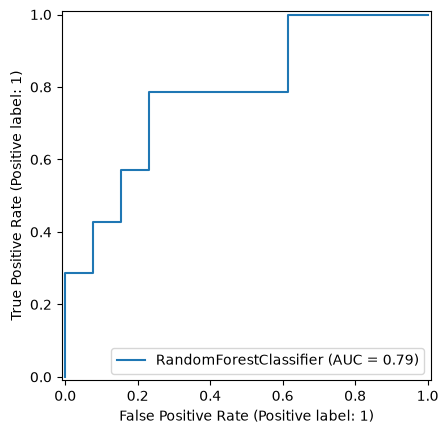

In [17]:
#ROC curves
best_model = models["Random Forest"]

best_features = feature_sets["RF10"]

best_model.fit(
    X_train[best_features],
    y_train
)

RocCurveDisplay.from_estimator(
    best_model,
    X_test[best_features],
    y_test
)

plt.show()

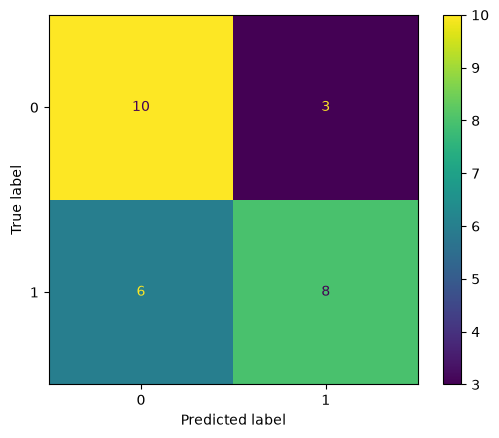

In [21]:
pred = best_model.predict(
    X_test[best_features]
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.show()

In [25]:
results.to_csv("../data/model_comparison.csv", index=False)

In [26]:
best = results.sort_values("ROC-AUC", ascending=False).iloc[0]

best.to_frame().T.to_csv("../data/best_model_summary.csv", index=False)

In [27]:
import json

feature_sets_json = {
    k: list(v) for k, v in feature_sets.items()
}

with open("../data/feature_sets.json", "w") as f:
    json.dump(feature_sets_json, f, indent=4)

/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/miniforge3/envs/microbiome_ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: Fu

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,All,Logistic Regression,0.481481,0.500000,0.285714,0.363636,0.428571
1,All,Random Forest,0.740741,0.818182,0.642857,0.720000,0.686813
2,All,SVM,0.629630,0.666667,0.571429,0.615385,0.684066
3,All,Gradient Boosting,0.703704,0.750000,0.642857,0.692308,0.670330
4,RF10,Logistic Regression,0.518519,0.545455,0.428571,0.480000,0.593407
5,RF10,Random Forest,0.666667,0.727273,0.571429,0.640000,0.785714
6,RF10,SVM,0.518519,0.571429,0.285714,0.380952,0.648352
7,RF10,Gradient Boosting,0.666667,0.777778,0.500000,0.608696,0.681319
8,RF20,Logistic Regression,0.555556,0.583333,0.500000,0.538462,0.538462
9,RF20,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813


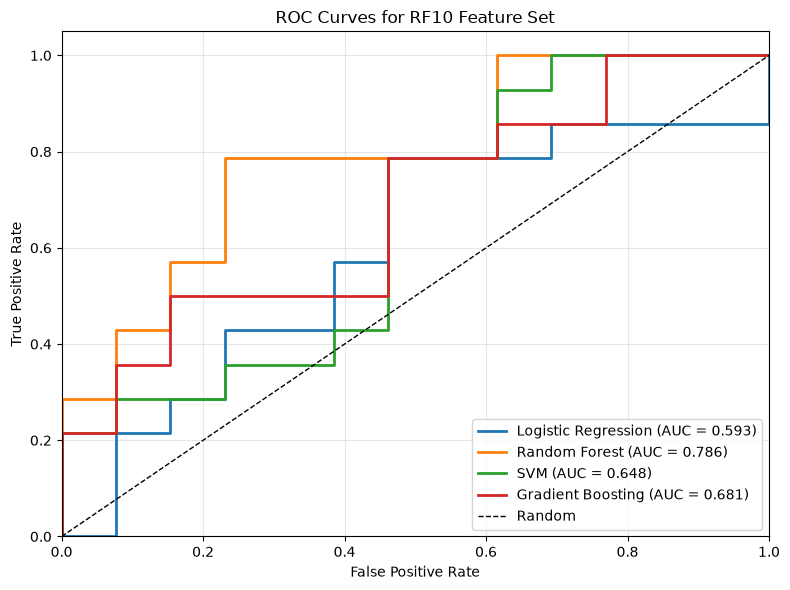

In [18]:
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression":

        Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000))
        ]),

    "Random Forest":

        RandomForestClassifier(
            n_estimators=500,
            random_state=42
        ),

    "SVM":

        Pipeline([
            ("scale", StandardScaler()),
            ("model", SVC(
                probability=True,
                random_state=42
            ))
        ]),

    "Gradient Boosting":

        HistGradientBoostingClassifier(
            random_state=42
        )

}

# ==========================================================
# Evaluate Models
# ==========================================================

results = []

# Store ROC information for RF10
roc_data = {}

for fs_name, features in feature_sets.items():

    Xtr = X_train[features]
    Xte = X_test[features]

    for model_name, model in models.items():

        model.fit(Xtr, y_train)

        pred = model.predict(Xte)

        prob = model.predict_proba(Xte)[:, 1]

        # Save ROC curve data only for RF10
        if fs_name == "RF10":

            fpr, tpr, _ = roc_curve(y_test, prob)

            roc_data[model_name] = {

                "fpr": fpr,
                "tpr": tpr,
                "auc": roc_auc_score(y_test, prob)

            }

        results.append({

            "Feature Set": fs_name,

            "Model": model_name,

            "Accuracy":
                accuracy_score(y_test, pred),

            "Precision":
                precision_score(y_test, pred),

            "Recall":
                recall_score(y_test, pred),

            "F1":
                f1_score(y_test, pred),

            "ROC-AUC":
                roc_auc_score(y_test, prob)

        })

# ==========================================================
# Results Table
# ==========================================================

results_df = pd.DataFrame(results)

display(results_df)

# ==========================================================
# Plot ROC Curves (RF10)
# ==========================================================

plt.figure(figsize=(8,6))

for model_name, values in roc_data.items():

    plt.plot(
        values["fpr"],
        values["tpr"],
        linewidth=2,
        label=f'{model_name} (AUC = {values["auc"]:.3f})'
    )

# Random classifier
plt.plot([0,1], [0,1], 'k--', linewidth=1, label="Random")

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for RF10 Feature Set")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("ROC_RF10.png", dpi=600, bbox_inches="tight")

plt.show()

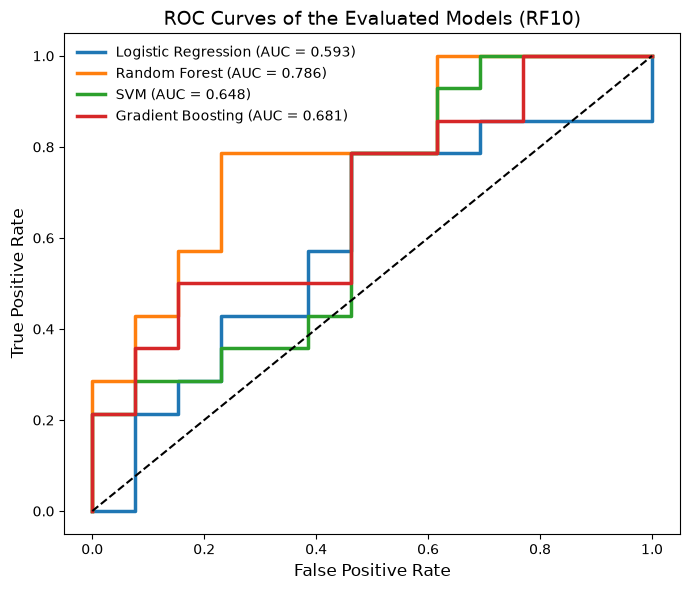

In [19]:
plt.figure(figsize=(7,6))

for model_name, values in roc_data.items():

    plt.plot(
        values["fpr"],
        values["tpr"],
        linewidth=2.5,
        label=f'{model_name} (AUC = {values["auc"]:.3f})'
    )

plt.plot([0,1],[0,1],'k--',lw=1.5)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves of the Evaluated Models (RF10)", fontsize=14)

plt.legend(frameon=False)

plt.grid(False)

plt.tight_layout()

plt.savefig("ROC_RF10.png", dpi=600)
plt.show()

In [20]:
results_df


,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,All,Logistic Regression,0.481481,0.500000,0.285714,0.363636,0.428571
1,All,Random Forest,0.740741,0.818182,0.642857,0.720000,0.686813
2,All,SVM,0.629630,0.666667,0.571429,0.615385,0.684066
3,All,Gradient Boosting,0.703704,0.750000,0.642857,0.692308,0.670330
4,RF10,Logistic Regression,0.518519,0.545455,0.428571,0.480000,0.593407
5,RF10,Random Forest,0.666667,0.727273,0.571429,0.640000,0.785714
6,RF10,SVM,0.518519,0.571429,0.285714,0.380952,0.648352
7,RF10,Gradient Boosting,0.666667,0.777778,0.500000,0.608696,0.681319
8,RF20,Logistic Regression,0.555556,0.583333,0.500000,0.538462,0.538462
9,RF20,Random Forest,0.666667,0.727273,0.571429,0.640000,0.686813


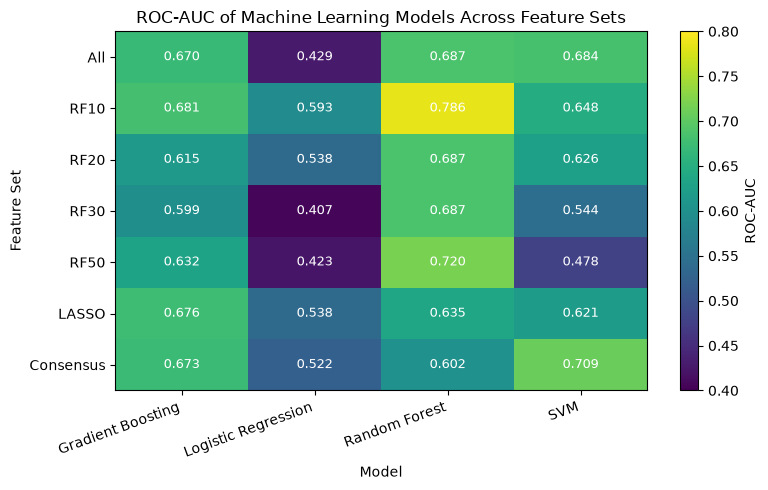

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Pivot the results into a matrix
heatmap_data = results_df.pivot(
    index="Feature Set",
    columns="Model",
    values="ROC-AUC"
)

# Arrange feature sets in the desired order
feature_order = [
    "All",
    "RF10",
    "RF20",
    "RF30",
    "RF50",
    "LASSO",
    "Consensus"
]

heatmap_data = heatmap_data.reindex(feature_order)

# Plot
fig, ax = plt.subplots(figsize=(8,5))

#im = ax.imshow(heatmap_data, aspect="auto")
im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="viridis",   # yellow → orange → red
    vmin=0.40,
    vmax=0.80
)

# Tick labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=20, ha="right")

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Write values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9
        )

# Color bar
cbar = plt.colorbar(im)
cbar.set_label("ROC-AUC")

plt.title("ROC-AUC of Machine Learning Models Across Feature Sets")
plt.xlabel("Model")
plt.ylabel("Feature Set")

plt.tight_layout()

plt.savefig("../figures/ROC_AUC_heatmap.png", dpi=800, bbox_inches="tight")

plt.show()